# Perceptron with Sigmoid Function

### Creating data

In [1]:
import numpy as np
from sklearn.datasets import make_classification

In [7]:
x, y = make_classification(n_samples=100, n_features=2, n_informative=1, n_redundant=0,
                          n_classes=2, n_clusters_per_class=1, random_state=41, hypercube=False, class_sep=30)

In [8]:
x[:5]

array([[ 0.82321545, -0.11697552],
       [ 0.37514771, -0.73115232],
       [ 0.26947761, -0.7081059 ],
       [-4.98744874, -2.01199214],
       [ 0.4231285 ,  1.63493163]])

### Plotting data

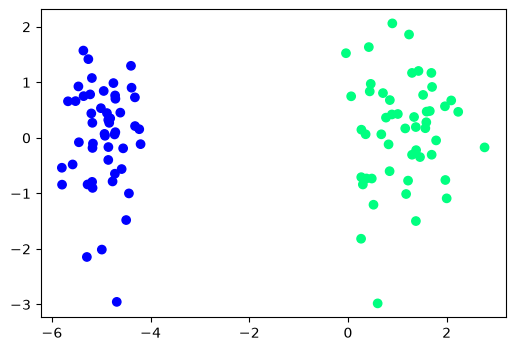

In [9]:
from matplotlib import pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(x[:,0], x[:,1], c=y, cmap='winter')
plt.show()

### Defining Perceptron Algorithm

In [24]:
def perceptron(x, y):
    x = np.insert(x, 0, 1, axis=1)
    weights = np.ones(x.shape[1])
    lr = 0.1

    for _ in range(1000):
        r_pt = np.random.randint(0, 100)
        y_hat = step(np.dot(weights, x[r_pt]))
        weights = weights + lr*(y[r_pt] - y_hat)*x[r_pt]

    coef_ = weights[1:]
    intercept_ = weights[0]
    return coef_, intercept_

In [25]:
def step(z):
    return 0 if z<0 else 1

In [26]:
coef, intercept = perceptron(x, y)

In [27]:
coef, intercept

(array([1.1134548 , 0.33857969]), np.float64(1.3000000000000003))

### Plotting step function model

In [53]:
m = -(coef[0]/coef[1])
b = -(intercept/coef[1])

In [41]:
x_input = np.linspace(-6, 3, 100)
y_input = m*x_input + b

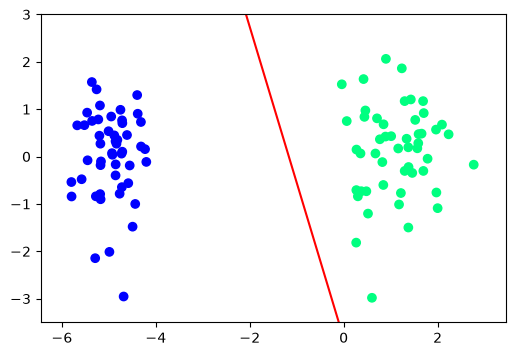

In [42]:
plt.figure(figsize=(6,4))
plt.scatter(x[:,0], x[:,1], c=y, cmap='winter')
plt.plot(x_input, y_input, c='r')
plt.ylim(-3.5, 3)
plt.show()

### Implementing actual Logistic Regression model from scikit-learn

In [33]:
from sklearn.linear_model import LogisticRegression

In [34]:
log_reg = LogisticRegression()
log_reg.fit(x, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [35]:
log_reg.coef_, log_reg.intercept_

(array([[1.77255101, 0.01190507]]), array([3.54700273]))

In [40]:
m1 = -(log_reg.coef_[0][0]/log_reg.coef_[0][1])
b1 = -(log_reg.intercept_/log_reg.coef_[0][1])

In [43]:
x_input1 = np.linspace(-6, 3, 100)
y_input1 = m1*x_input1 + b1

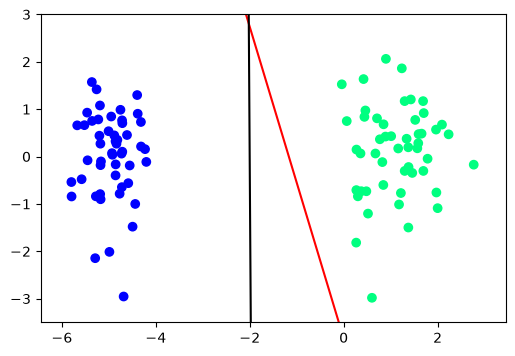

In [46]:
plt.figure(figsize=(6,4))
plt.scatter(x[:,0], x[:,1], c=y, cmap='winter')
plt.plot(x_input, y_input, c='r')
plt.plot(x_input1, y_input1, c='black')
plt.ylim(-3.5, 3)
plt.show()

### Implementing perceptron trick with **Sigmoid Function**

In [59]:
def perceptron1(x, y):
    x = np.insert(x, 0, 1, axis=1)
    weights = np.ones(x.shape[1])
    lr = 0.1

    for _ in range(1000):
        r_pt = np.random.randint(0, 100)
        y_hat = sigmoid(np.dot(weights, x[r_pt]))
        weights = weights + lr*(y[r_pt]-y_hat)*x[r_pt]

    coef_ = weights[1:]
    intercept_ = weights[0]
    return coef_, intercept_

In [60]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [61]:
coef1, intercept1 = perceptron1(x, y)

In [63]:
coef1, intercept1

(array([2.28347801, 0.1563477 ]), np.float64(2.669236208303483))

In [64]:
m2 = -(coef1[0]/coef1[1])
b2 = -(intercept1/coef1[1])

In [65]:
x_input2 = np.linspace(-6, 3, 100)
y_input2 = m2*x_input2 + b2

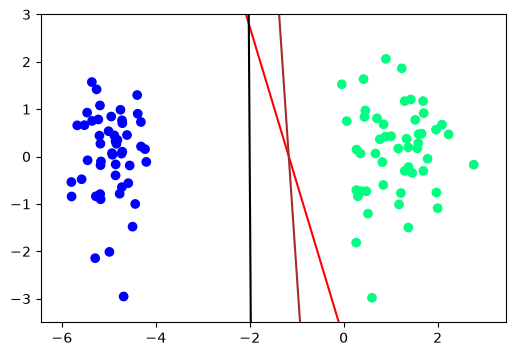

In [66]:
plt.figure(figsize=(6,4))
plt.scatter(x[:,0], x[:,1], c=y, cmap='winter')
plt.plot(x_input, y_input, c='r')
plt.plot(x_input1, y_input1, c='black')
plt.plot(x_input2, y_input2, c='brown')
plt.ylim(-3.5, 3)
plt.show()